# Assignment 1: PI-RADS Classification (Zero-Shot Proxy Approach)
**Objective**: Classify prostate lesions into three groups:
- Class 0: PI-RADS 1-2 (low)
- Class 1: PI-RADS 3 (indeterminate)
- Class 2: PI-RADS 4-5 (high)

**Methodology (Option 3)**: Since the `PICG2scoring` model does not have publicly released pre-trained weights, we take a purely **zero-shot** approach by using the official `PI-CAI` U-Net model as a proxy. The PI-CAI model outputs a continuous suspicion score $[0, 1]$. We will map this risk score to clinical PI-RADS classes using heuristic thresholds, completely bypassing the need to train a model from scratch!

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Paths (Update if needed for Kaggle)
PATIENT_SCORES_CSV = r"output\patient_scores.csv" # You must upload this file generated by evaluate.py
LABELS_CSV = r"dataset/labels_dev.csv" 


### 1. Load Data & Map PI-RADS to Classes

In [7]:
try:
    scores_df = pd.read_csv(PATIENT_SCORES_CSV)
    labels_df = pd.read_csv(LABELS_CSV)
    
    # Map clinical PI-RADS groups to the assignment's 3 classes
    def map_pirads_class(group):
        if group == "1-2": return 0
        if group == "3": return 1
        if group in ["4", "5"]: return 2
        return -1
        
    labels_df["pirads_class"] = labels_df["pirads_group"].apply(map_pirads_class)
    
    # Merge datasets
    df = pd.merge(scores_df, labels_df, on="code", how="inner")
    print(f"Successfully loaded {len(df)} cases for analysis.")
except FileNotFoundError:
    print(f"Error: Could not find {PATIENT_SCORES_CSV} or {LABELS_CSV}. Ensure they are uploaded.")


Successfully loaded 29 cases for analysis.


### 2. Statistical Correlation (Suspicion Score vs. PI-RADS)
We visualize how the PI-CAI zero-shot suspicion score distributes across clinical PI-RADS groups.

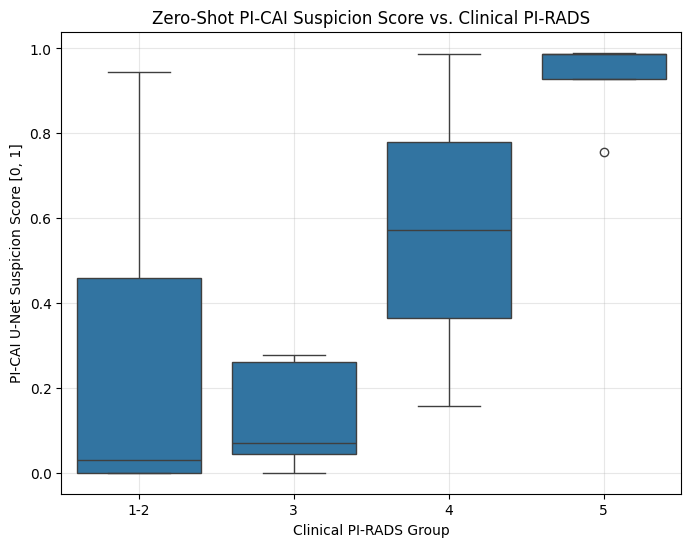

Mean PI-CAI Risk Score per PI-RADS Group:
pirads_group
1-2    0.246755
3      0.130273
4      0.572935
5      0.929941
Name: score, dtype: float64


In [8]:
if 'df' in locals():
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="pirads_group", y="score", data=df, order=["1-2", "3", "4", "5"])
    plt.title("Zero-Shot PI-CAI Suspicion Score vs. Clinical PI-RADS")
    plt.xlabel("Clinical PI-RADS Group")
    plt.ylabel("PI-CAI U-Net Suspicion Score [0, 1]")
    plt.grid(alpha=0.3)
    plt.show()
    
    mean_scores = df.groupby("pirads_group")["score"].mean().sort_index()
    print("Mean PI-CAI Risk Score per PI-RADS Group:")
    print(mean_scores)


### 3. Zero-Shot Proxy Thresholding
Using simple logical thresholds to divide the continuous `[0, 1]` risk score into the 3 PI-RADS classes.

Evaluating Thresholds (Low=0.2, High=0.6) for 3-Class Prediction:
Classes: 0 (PI-RADS 1-2), 1 (PI-RADS 3), 2 (PI-RADS 4-5)
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.72      0.74        18
           1       0.67      0.40      0.50         5
           2       0.56      0.83      0.67         6

    accuracy                           0.69        29
   macro avg       0.66      0.65      0.64        29
weighted avg       0.70      0.69      0.69        29



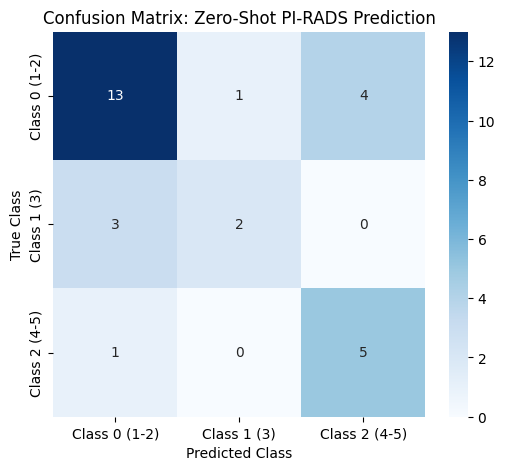

In [9]:
if 'df' in locals():
    # Define thresholds
    thresh_low = 0.20
    thresh_high = 0.60
    
    def predict_class(score):
        if score < thresh_low: return 0
        elif score < thresh_high: return 1
        else: return 2
        
    df["predicted_class"] = df["score"].apply(predict_class)
    
    print(f"Evaluating Thresholds (Low={thresh_low}, High={thresh_high}) for 3-Class Prediction:")
    print("Classes: 0 (PI-RADS 1-2), 1 (PI-RADS 3), 2 (PI-RADS 4-5)")
    print("-" * 60)
    print(classification_report(df["pirads_class"], df["predicted_class"]))
    
    # Confusion Matrix
    cm = confusion_matrix(df["pirads_class"], df["predicted_class"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Class 0 (1-2)', 'Class 1 (3)', 'Class 2 (4-5)'],
                yticklabels=['Class 0 (1-2)', 'Class 1 (3)', 'Class 2 (4-5)'])
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("Confusion Matrix: Zero-Shot PI-RADS Prediction")
    plt.show()
